In [1]:
import os
drive_path = r"../../Drive/MyDrive/ch9"

In [2]:
import os
import wget
import tarfile


In [3]:
os.mkdir('../../Drive/MyDrive/ch9')

FileExistsError: [WinError 183] Cannot create a file when that file already exists: '../../Drive/MyDrive/ch9'

In [4]:
os.chdir('../../Drive/MyDrive/ch9')

In [12]:
DATASET_URL = 'http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz'

In [13]:
wget.download(DATASET_URL)

100% [....................................................................] 1489096277 / 1489096277

'speech_commands_v0.01.tar.gz'

In [14]:
ARCHIVE = os.path.basename(DATASET_URL)

In [15]:
with tarfile.open(ARCHIVE, 'r:gz') as tar:
  tar.extractall(path='data/train')

os.remove(ARCHIVE)

C:\Users\yathi\AppData\Local\Temp\ipykernel_19708\1425456652.py:2: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='data/train')


In [5]:
os.listdir("data/train")

['bed',
 'bird',
 'cat',
 'dog',
 'down',
 'eight',
 'five',
 'four',
 'go',
 'happy',
 'house',
 'left',
 'LICENSE',
 'marvin',
 'nine',
 'no',
 'off',
 'on',
 'one',
 'README.md',
 'right',
 'seven',
 'sheila',
 'six',
 'stop',
 'testing_list.txt',
 'three',
 'tree',
 'two',
 'up',
 'validation_list.txt',
 'wow',
 'yes',
 'zero',
 '_background_noise_']

In [6]:
# ls -1 data/train/bed | wc -l

len(os.listdir("data/train/bed"))

1713

In [8]:
import librosa
x, sr  = librosa.load('data/train/bed/58df33b5_nohash_0.wav')

In [9]:
import IPython.display as ipd
ipd.Audio(x, rate=sr)

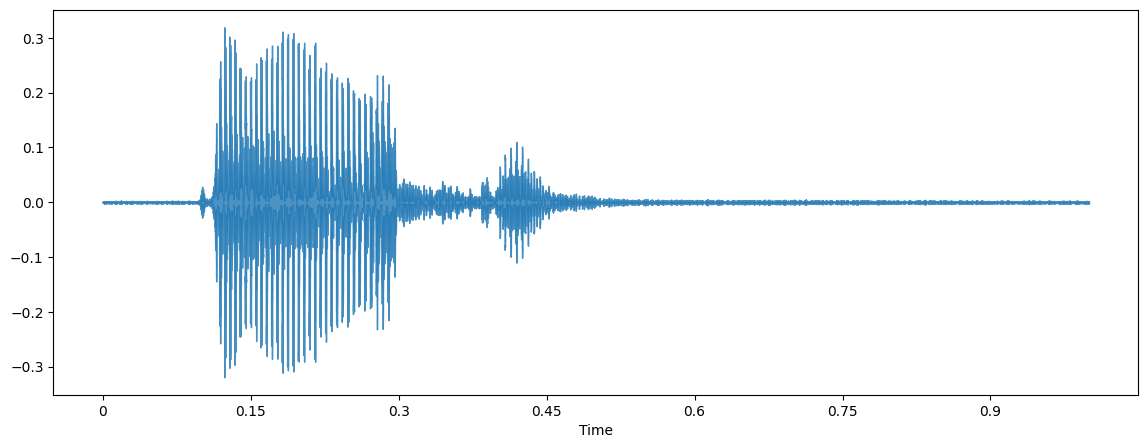

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(14, 5))
librosa.display.waveshow(x, sr=sr, alpha=0.8)  # also called pressure-time plot

In [12]:
x.shape

(22050,)

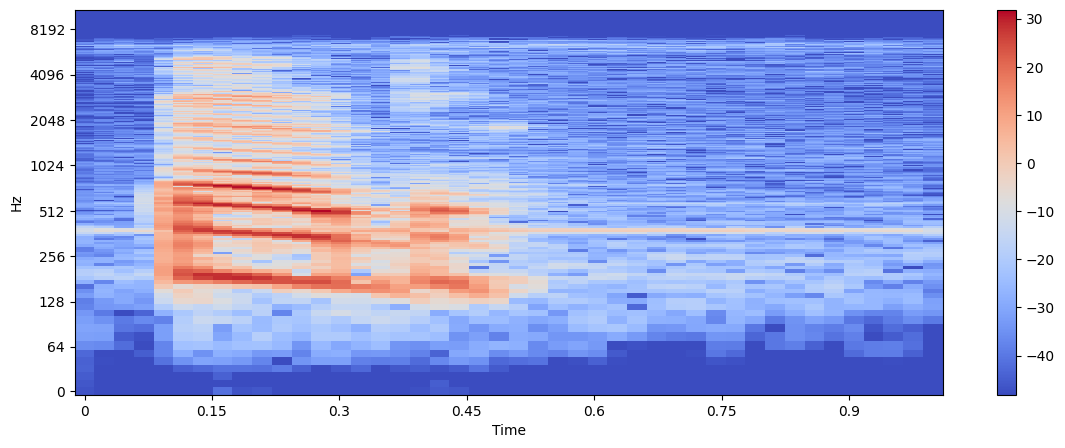

In [13]:
X = librosa.stft(x)  # short-term fourier transform
Xdb = librosa.amplitude_to_db(abs(X))
plt.figure(figsize=(14, 5))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log')
plt.colorbar()

In [14]:
from tqdm.notebook import tqdm

def vectorize_directory(dirpath, label=0):
  features = []
  labels = [0]
  files = os.listdir(dirpath)
  for filename in tqdm(files):
    x, _ = librosa.load(
        os.path.join(dirpath, filename)
    )
    features.append(x)
  return features, [label] * len(features)

features, labels = vectorize_directory('data/train/bed/')

  0%|          | 0/1713 [00:00<?, ?it/s]

In [15]:
f, l = vectorize_directory('data/train/bird/', 1)
features.extend(f)
labels.extend(l)
f, l = vectorize_directory('data/train/tree/', 2)
features.extend(f)
labels.extend(l)

  0%|          | 0/1731 [00:00<?, ?it/s]

  0%|          | 0/1733 [00:00<?, ?it/s]

In [16]:
import pickle
pickle.dump([features, labels], open('dataset.pickle', 'wb'))

In [17]:
import pickle
features, labels = pickle.load(open('dataset.pickle', 'rb'))

In [18]:
len(features)

5177

In [19]:
features[0]

array([ 8.20422138e-05,  4.09124368e-05,  7.42688135e-05, ...,
       -1.03294806e-04,  3.70733615e-05,  1.16690600e-04], dtype=float32)

(array([1.000e+00, 2.000e+00, 6.000e+00, 0.000e+00, 8.000e+00, 7.000e+00,
        5.000e+00, 1.600e+01, 1.600e+01, 2.000e+01, 1.800e+01, 4.900e+01,
        2.900e+01, 5.100e+01, 8.600e+01, 4.300e+01, 5.200e+01, 1.250e+02,
        6.000e+00, 4.637e+03]),
 array([ 9409.  , 10041.05, 10673.1 , 11305.15, 11937.2 , 12569.25,
        13201.3 , 13833.35, 14465.4 , 15097.45, 15729.5 , 16361.55,
        16993.6 , 17625.65, 18257.7 , 18889.75, 19521.8 , 20153.85,
        20785.9 , 21417.95, 22050.  ]),
 <BarContainer object of 20 artists>)

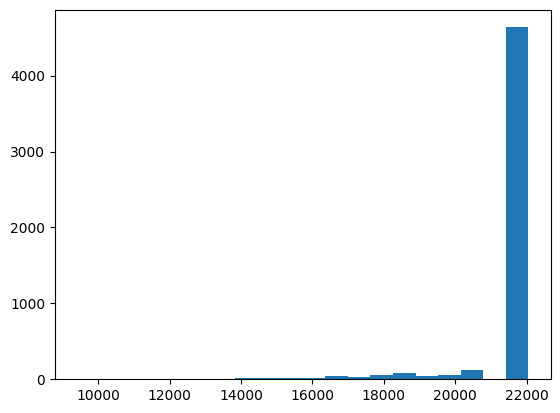

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.hist([f.shape[0] for f in features], bins=20)

In [21]:
indexes = [i for i, f in enumerate(features) if f.shape[0] >= 22050]
features = [f for i, f in enumerate(features) if i in indexes]
labels = [f for i, f in enumerate(labels) if i in indexes]

(array([   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0., 4526.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.]),
 array([22049.5 , 22049.55, 22049.6 , 22049.65, 22049.7 , 22049.75,
        22049.8 , 22049.85, 22049.9 , 22049.95, 22050.  , 22050.05,
        22050.1 , 22050.15, 22050.2 , 22050.25, 22050.3 , 22050.35,
        22050.4 , 22050.45, 22050.5 ]),
 <BarContainer object of 20 artists>)

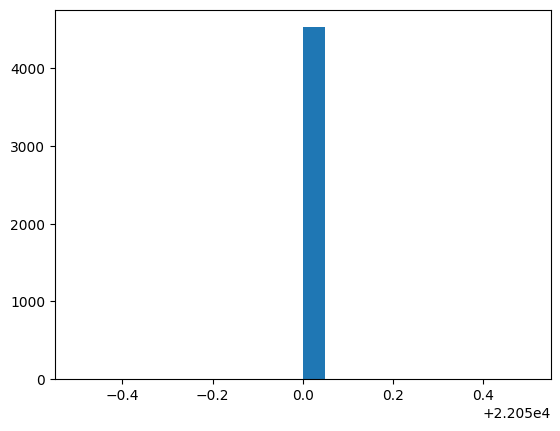

In [22]:
plt.hist([f.shape[0] for f in features], bins=20)

In [23]:
import numpy as np

features = np.concatenate([f.reshape(1, -1) for f in features], axis=0)

In [24]:
features.shape

(4526, 22050)

In [25]:
labels = np.array(labels)

In [26]:
classes = ['bed', 'bird', 'tree']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  features, labels, test_size=0.33, random_state=42
)

In [28]:
X_train.shape

(3032, 22050)

In [30]:
import tensorflow.keras as keras
from tensorflow.keras.layers import *
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K


def preprocess(x):
    x = (x + 0.8) / 7.0
    x = K.clip(x, -5, 5)
    return x

def relu6(x):
    return K.relu(x, max_value=6)

Preprocess = Lambda(preprocess)

def conv_layer(x, num_filters=100, k=3, strides=2):
    x = Conv1D(
          num_filters,
          (k),
          padding='valid',
          use_bias=False,
          kernel_regularizer=l2(1e-6)
        )(x)
    x = BatchNormalization()(x)
    x = Activation(relu6)(x)
    x = MaxPool1D(pool_size=num_filters, strides=None, padding='valid')(x)
    return x

def create_model(classes, nlayers=1, filters=100, k=100):
    input_layer = Input(shape=[features.shape[1]])
    x = Preprocess(input_layer)
    x = Reshape([features.shape[1], 1])(x)
    for _ in range(nlayers):
        x = conv_layer(x, num_filters=filters, k=k)
        x = Reshape([219 * filters])(x)
        x = Dense(
            units=len(classes), activation='softmax',
            kernel_regularizer=l2(1e-2)
        )(x)
    model = Model(input_layer, x, name='conv1d_sound')
    model.compile(
        optimizer=keras.optimizers.Adam(lr=3e-4),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.sparse_categorical_accuracy])
    model.summary()
    return model

model = create_model(classes)


Model: "conv1d_sound"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 22050)]           0         
                                                                 
 lambda (Lambda)             (None, 22050)             0         
                                                                 
 reshape (Reshape)           (None, 22050, 1)          0         
                                                                 
 conv1d (Conv1D)             (None, 21951, 100)        10000     
                                                                 
 batch_normalization (Batch  (None, 21951, 100)        400       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 21951, 100)        0         
                                                      

In [31]:
model.fit(X_train, y_train, epochs=30)

Epoch 1/30



95/95 [==============================] - 34s 345ms/step - loss: 0.8825 - sparse_categorical_accuracy: 0.6659
Epoch 2/30
95/95 [==============================] - 32s 334ms/step - loss: 0.6521 - sparse_categorical_accuracy: 0.8087
Epoch 3/30
95/95 [==============================] - 31s 331ms/step - loss: 0.5829 - sparse_categorical_accuracy: 0.8282
Epoch 4/30
95/95 [==============================] - 31s 328ms/step - loss: 0.5235 - sparse_categorical_accuracy: 0.8615
Epoch 5/30
95/95 [==============================] - 31s 331ms/step - loss: 0.4891 - sparse_categorical_accuracy: 0.8671
Epoch 6/30
95/95 [==============================] - 31s 322ms/step - loss: 0.4800 - sparse_categorical_accuracy: 0.8790
Epoch 7/30
95/95 [==============================] - 31s 323ms/step - loss: 0.5063 - sparse_categorical_accuracy: 0.8546
Epoch 8/30
95/95 [==============================] - 31s 329ms/step - loss: 0.4583 - sparse_categorical_accuracy: 0.8740
Epoch 9/30
95/95 [==============================] -

In [32]:
import sklearn

predicted = model.predict(X_test)
print('accuracy: {:.3f}'.format(
    sklearn.metrics.accuracy_score(y_test, predicted.argmax(axis=1))
))

47/47 [==============================] - 3s 60ms/step
accuracy: 0.354


(array([  22.,    0.,    0.,    0.,    0., 1464.,    0.,    0.,    0.,
           8.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

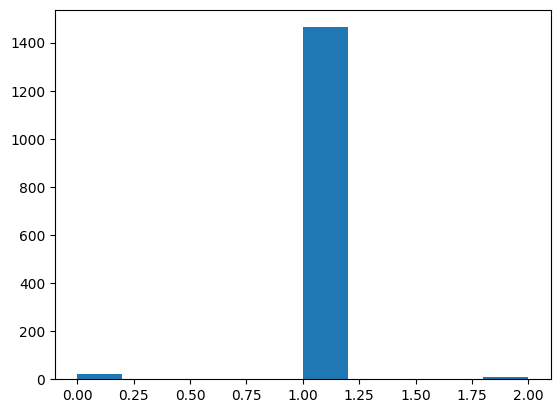

In [33]:
plt.hist(predicted.argmax(axis=1))

(array([1484.,    0.,    0.,    0.,    0., 1521.,    0.,    0.,    0.,
        1521.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

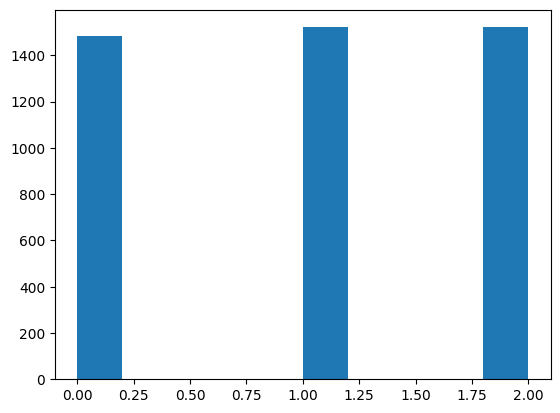

In [34]:
plt.hist(labels)